
##### Sets & Parameters

- $N = \{0, 1, \dots, n-1\}$: set of nodes (0 = depot)
- $d_{ij} \ge 0$: distance from node $i$ to node $j$

---

##### Decision Variables

- $
x_{ij} \in \{0,1\} \quad \forall i,j \in N, \; i \neq j
$

> $
x_{ij} = \begin{cases} 1 & \text{if edge } i \rightarrow j \text{ is selected} \\ 0 & \text{otherwise} \end{cases}
$

$$
\boxed{
\begin{aligned}
\min \quad & \sum_{i \in N} \sum_{\substack{j \in N \\ j \neq i}} d_{ij} x_{ij} \\[2mm]
\text{s.t.} \quad & \sum_{\substack{j \in N \\ j \neq i}} x_{ij} = 1 && \forall i \in N \\[2mm]
& \sum_{\substack{i \in N \\ i \neq j}} x_{ij} = 1 && \forall j \in N \\[2mm]
& \sum_{i \in S} \sum_{\substack{j \in S \\ j \neq i}} x_{ij} \le |S| - 1 && \forall S \subset N, \; S \neq \emptyset \\[2mm]
& x_{ij} \in \{0,1\} && \forall i,j \in N, \; i \neq j
\end{aligned}
}
$$

>The formulation above is the linear (MILP) formulation of the TSP. In the CP-SAT implementation, instead of explicitly modeling subtour elimination constraints, we use the AddCircuit constraint to directly enforce a valid circuit.

>**Arc Pruning**: To reduce the size of the CP-SAT model, we performed arc pruning by removing edges whose distance exceeded a given threshold. Several threshold values were tested to find a smaller model while preserving the optimal solution for the given instance.

In [1]:
import pandas as pd
df = pd.read_csv("data/points.csv")

points = {
   row.node: (row.x, row.y) 
    for row in df.itertuples()
}

df.head()
# points = {
#     0: (1, 7),
#     1: (3, 2),
#     2: (8, 8),
#     3: (9, 3),
#     4: (5, 5),
#     5: (7, 1)
# }

,node,x,y
0,0,4,82
1,1,17,45
2,2,23,91
3,3,31,27
4,4,38,68


In [2]:
import math 
N = points.keys()
distance = {}
for i in N:
    for j in N:
        if i != j:
            x1, y1 = points[i]
            x2, y2 = points[j]

            distance[i,j] = math.sqrt(
                (x1-x2)**2 + (y1-y2)**2
            )
        else:
            distance[i,j] = 0

In [3]:
from ortools.sat.python import cp_model
import time

In [8]:
thresholds = [15, 20, 25, 30, math.inf]

for t in thresholds:
    model = cp_model.CpModel()
    arcs = []
    for i in N:
        for j in N:
            if i!=j and distance[i,j] <= t:
                
                x = model.NewBoolVar(f"x[{i},{j}]")
                arcs.append((i,j,x))
                
    model.AddCircuit(arcs)
    
    
    model.Minimize(sum(
        distance[i,j] * x for i,j,x in arcs))
    
    solver = cp_model.CpSolver()

    startt = time.perf_counter()    
    status= solver.Solve(model)
    endt = time.perf_counter()    
    wallt = f"{endt-startt}s"

    if status == cp_model.OPTIMAL:
        print(f"treshold={t}, arcs = {len(arcs)}, Obj={solver.ObjectiveValue()}, walltime: {wallt}")
    elif status == cp_model.INFEASIBLE:
        print(f"treshold={t}, arcs = {len(arcs)}, INFEASIBLE, walltime: {wallt}")


treshold=15, arcs = 544, INFEASIBLE, walltime: 0.0016497889992024284s
treshold=20, arcs = 978, Obj=877.3520169565495, walltime: 3.7666456920014753s
treshold=25, arcs = 1470, Obj=877.3520169565496, walltime: 5.559683158000553s
treshold=30, arcs = 2110, Obj=877.3520169565496, walltime: 4.766833145000419s
treshold=inf, arcs = 9900, Obj=877.3520169565495, walltime: 9.24565966299997s


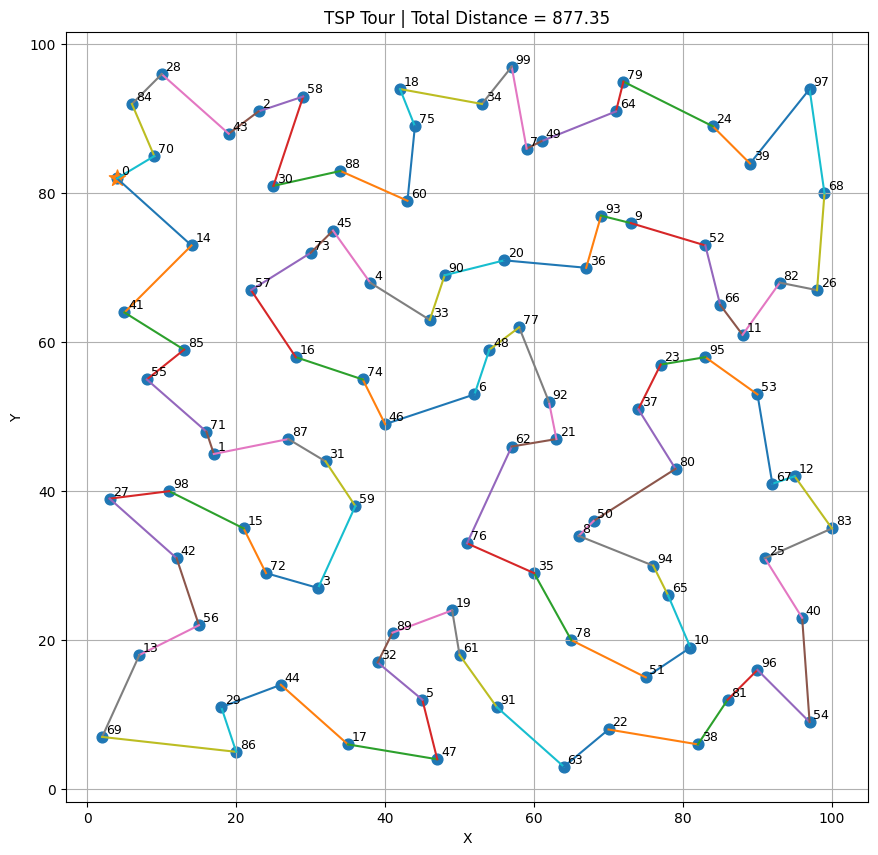

In [9]:
import matplotlib.pyplot as plt

# Extract TSP tour
tour = [0]
current = 0

while True:
    for i, j, x in arcs:
        if i == current and solver.Value(x):
            current = j
            break

    tour.append(current)

    if current == 0:
        break


# Visualization

plt.figure(figsize=(12, 10))
# Draw points
plt.scatter( [points[i][0] for i in points], [points[i][1] for i in points], s=60 )
# Draw TSP tour
for k in range(len(tour) - 1):
    i = tour[k]
    j = tour[k + 1]
    plt.plot( [points[i][0], points[j][0]], [points[i][1], points[j][1]], linewidth=1.5 )

# Labels
for i, (x, y) in points.items():
    plt.text( x + 0.5, y + 0.5, str(i), fontsize=9 )

# Highlight depot
plt.scatter( points[0][0], points[0][1], s=150, marker="*" )

plt.title(f"TSP Tour | Total Distance = {solver.ObjectiveValue():.2f}")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.gca().set_aspect("equal", adjustable="box")

plt.show()